<a href="https://colab.research.google.com/github/manideep225/manideep225/blob/main/Deep_Learning_with_PyTorch_Object_Localization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Intro Task, Object Localization

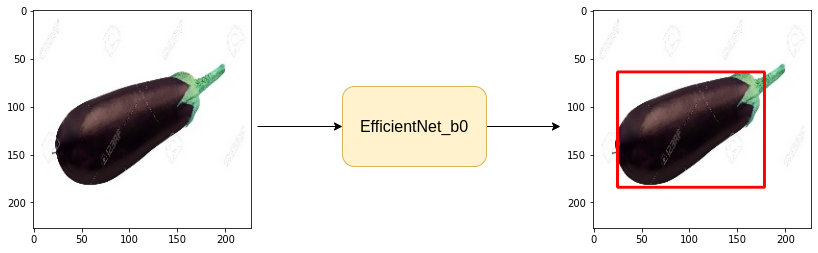

In [1]:
# install libraries/packages/modules

!pip install -U git+https://github.com/albumentations-team/albumentations
!pip install timm
!pip install --upgrade opencv-contrib-python

  Cloning https://github.com/albumentations-team/albumentations to /tmp/pip-req-build-1vhdlyle
  Running command git clone --filter=blob:none --quiet https://github.com/albumentations-team/albumentations /tmp/pip-req-build-1vhdlyle
  Resolved https://github.com/albumentations-team/albumentations to commit 12f5801973b6a93aeb04199c169dd661cbd7304d
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.8/53.8 kB 3.0 MB/s eta 0:00:00
  Using cached nvidia_cuda_nvrtc_cu12-12.1.105-py3-none-manylinux1_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_cuda_runtime_cu12-12.1.105-py3-none-manylinux1_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_cuda_cupti_cu12-12.1.105-py3-none-manylinux1_x86_64.whl.metadata (1.6 kB)
  Using cached nvidia_cudnn_cu12-8.9.2.26-py3-none-manylinux1_x86_64.whl.metadata (1.6 kB)
  Using cached nvidia_cublas_cu12-12.1.3.1-py3-none-many

In [2]:
# Download Dataset

!git clone https://github.com/parth1620/object-localization-dataset.git

Cloning into 'object-localization-dataset'...
remote: Enumerating objects: 203, done.
remote: Counting objects: 100% (203/203), done.
remote: Compressing objects: 100% (203/203), done.
remote: Total 203 (delta 3), reused 195 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (203/203), 2.73 MiB | 25.93 MiB/s, done.
Resolving deltas: 100% (3/3), done.


In [3]:
import pandas as pd
import numpy as np
import cv2
import matplotlib.pyplot as plt
import torch
from tqdm.notebook import tqdm

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

In [4]:
import sys
sys.path.append('/content/object-localization-dataset')

# Configurations

In [5]:
CSV_FILE = '/content/object-localization-dataset/train.csv'
DATA_DIR = '/content/object-localization-dataset/'

DEVICE = 'cuda'

BATCH_SIZE = 16
IMG_SIZE = 140

LR = 0.001 #LEARNING RATE
EPHOCS = 40
MODEL_NAME = 'efficientnet_b0'

NUM_COR = 4 # COORDINATES


In [6]:
# READ THE CSV FILE
df = pd.read_csv(CSV_FILE)
df

,img_path,xmin,ymin,xmax,ymax,width,height,label
0,train_images/mushroom_51.jpg,24,23,202,183,227,227,mushroom
1,train_images/eggplant_37.jpg,34,34,88,201,227,227,eggplant
2,train_images/mushroom_20.jpg,49,86,183,185,227,227,mushroom
3,train_images/eggplant_51.jpg,51,59,191,164,227,227,eggplant
4,train_images/eggplant_26.jpg,40,70,179,168,227,227,eggplant
...,...,...,...,...,...,...,...,...
181,train_images/eggplant_62.jpg,67,22,177,215,227,227,eggplant
182,train_images/cucumber_45.jpg,11,31,217,208,227,227,cucumber
183,train_images/mushroom_37.jpg,93,13,158,193,227,227,mushroom
184,train_images/eggplant_44.jpg,21,59,192,171,227,227,eggplant


# Understand the dataset

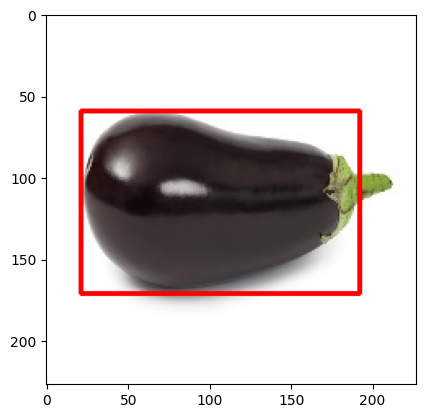

In [7]:
# Plot some of the images form the dataset
row = df.iloc[184] # select example number 2
img = cv2.imread(DATA_DIR + row.img_path) # read the image using opencv imread
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) # convert BGR to RGB

# show the bounding box
pt1 = (row.xmin, row.ymin)
pt2 = (row.xmax, row.ymax)
bnd_box_img = cv2.rectangle(img, pt1, pt2, (255,0,0), 2)
plt.imshow(bnd_box_img)


In [8]:
# Split the dataset into training and validation sets
train_df, valid_df = train_test_split(df, test_size = 0.20, random_state = 42)


# Augmentations

In [9]:
import albumentations as A  # well-known library for data augmentation tasks

In [11]:
train_augs = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.HorizontalFlip( p=0.5 ),
    A.VerticalFlip( p=0.5 ),
    A.Rotate()
], bbox_params=A.BboxParams(format='pascal_voc', label_fields=['class_labels'] ))

valid_augs = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
], bbox_params=A.BboxParams(format='pascal_voc', label_fields=['class_labels'] ))



# Create Custom Dataset

In [12]:
class ObjLocDataset( torch.utils.data.Dataset):

  def __init__(self, df, augmentations = None):
    self.df = df
    self.augmentations = augmentations

  def __len__(self):
    return len(self.df)

  def __getitem__(self, idx):
    row = self.df.iloc[idx]

    # get coordinates
    xmin = row.xmin
    ymin = row.ymin
    xmax = row.xmax
    ymax = row.ymax

    # create bbox
    bbox = [[xmin, ymin, xmax, ymax]] #albumention requires list of list as bbox

    # create image with bounding box
    img_path = DATA_DIR + row.img_path
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    if self.augmentations:
      data = self.augmentations(image = img, bboxes = bbox, class_labels=[None]) # as we are not doing classification, so we put None as class_labels
      img = data['image']
      bbox = data['bboxes'][0] # get access to list of list

    img = torch.from_numpy(img).permute(2, 0, 1)/255.0 # permute transform(h, w, c) -> (c, h, w) as pytorch required convention
    bbox = torch.Tensor(bbox)

    return img, bbox



In [13]:
# create train and valid set
trainset = ObjLocDataset( train_df, train_augs )
validset = ObjLocDataset( valid_df, valid_augs )


In [14]:
print(f"Total examples in the Train Set: {len(trainset)}")
print(f"Total examples in the Valid Set: {len(validset)}")


Total examples in the Train Set: 148
Total examples in the Valid Set: 38


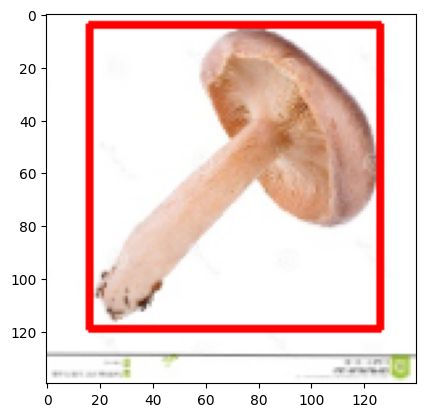

In [20]:
img, bbox = trainset[120]

#unpack the bbox
xmin, ymin, xmax, ymax = bbox

# create points for rectangle
pt1 = (int(xmin), int(ymin))
pt2 = (int(xmax), int(ymax))

# convert (h,w,c) convention for Numpy array
bnd_img = cv2.rectangle(img.permute(1, 2, 0).numpy(),pt1, pt2,(255,0,0),2)
plt.imshow(bnd_img)


# Load dataset into batches

In [16]:
trainloader = torch.utils.data.DataLoader( trainset, batch_size = BATCH_SIZE, shuffle = True )
validloader = torch.utils.data.DataLoader( validset, batch_size = BATCH_SIZE, shuffle = True )


In [17]:
print("Total no. batches in trainloader : {}".format(len(trainloader)))
print("Total no. batches in validloader : {}".format(len(validloader)))

Total no. batches in trainloader : 10
Total no. batches in validloader : 3


In [21]:
# load a single batch

for images, bboxes in trainloader:
  break;


print("Shape of one batch images : {}".format(images.shape)) #batch_number, channel, h, w
print("Shape of one batch bboxes : {}".format(bboxes.shape))


Shape of one batch images : torch.Size([16, 3, 140, 140])
Shape of one batch bboxes : torch.Size([16, 4])


# Create Model

In [22]:
from torch import nn
import timm

In [23]:
# Class to load a model
class ObjLocModel(nn.Module):
  def __init__(self):
    super(ObjLocModel, self).__init__()

    self.backbone = timm.create_model( MODEL_NAME, pretrained = True, num_classes = 4) # mostly return logit

  def forward( self, images, gt_bboxes = None):
    bboxes = self.backbone(images) # logit value of bboxes

    if gt_bboxes != None:
      loss = nn.MSELoss()(bboxes, gt_bboxes)
      return bboxes, loss

    return bboxes



In [25]:
model = ObjLocModel()
#transfer model to GPU
model.to(DEVICE); # put semicolon to suppress the architecture text

randm_img = torch.rand(1, 3, 140, 140).to(DEVICE)
model(randm_img).shape

torch.Size([1, 4])

# Create Train and Eval Function

In [26]:
def train_fn(model, dataloader, optimizer):
  total_loss = 0.0
  model.train() # specify the model in the training mode....Dropout layer should be ON

  for data in tqdm(dataloader): #tqdm to track the batches
    images, gt_bboxes = data
    images, gt_bboxes = images.to(DEVICE), gt_bboxes.to(DEVICE)

    bboxes, loss = model(images, gt_bboxes) # predicted bbox and loss
    #gradient calculation
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()


    total_loss += loss.item()

  return total_loss/len(dataloader)


In [27]:
def eval_fn(model, dataloader):
  total_loss = 0.0
  model.eval() # specify the model in the training mode....Dropout layer should be OFF

  with torch.no_grad(): # disable gardient caculation inside eval function
    for data in tqdm(dataloader): #tqdm to track the batches
      images, gt_bboxes = data
      images, gt_bboxes = images.to(DEVICE), gt_bboxes.to(DEVICE)

      bboxes, loss = model(images, gt_bboxes) # predicted bbox and loss
      total_loss += loss.item()

  return total_loss/len(dataloader)


#Training Loop

In [28]:
#declare the optimizer
optimizer = torch.optim.Adam( model.parameters(), lr = LR)


In [29]:
best_valid_loss = np.Inf # initial validation loss

for i in range(EPHOCS):

  train_loss = train_fn( model, trainloader, optimizer)
  valid_loss = eval_fn( model, validloader)

  if valid_loss < best_valid_loss: # save better model
    torch.save(model.state_dict(), 'best_model.pt')
    print("WEIGHTS_ARE-SAVED")
    best_valid_loss = valid_loss

  print(f"Epoch: {i + 1} train loss : {train_loss} valid loss : {valid_loss}")

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/3 [00:00<?, ?it/s]

WEIGHTS_ARE-SAVED
Epoch: 1 train loss : 5154.02880859375 valid loss : 9230.850911458334


  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/3 [00:00<?, ?it/s]

...

  0%|          | 0/3 [00:00<?, ?it/s]

Epoch: 39 train loss : 38.99916038513184 valid loss : 59.16510581970215


  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/3 [00:00<?, ?it/s]

Epoch: 40 train loss : 28.450970077514647 valid loss : 54.232059478759766


#Inference

In [30]:
import utils

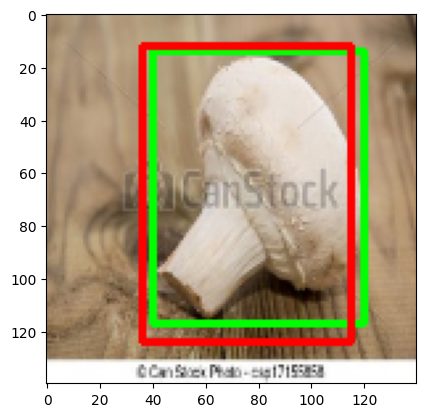

In [31]:
# compare gt_bbox with pred_bbox
model.load_state_dict(torch.load('best_model.pt')) # load saved best modle
model.eval()

with torch.no_grad():

  image, gt_bbox = validset[23] # (c,h,w)
  image = image.unsqueeze(0).to(DEVICE) # (bs, c, h, w)
  out_bbox = model(image) #predicted bbox

  utils.compare_plots(image, gt_bbox, out_bbox)


# For updates about upcoming and current guided projects follow me on...

Twitter : @parth_AI

Linkedin : www.linkedin.com/in/pdhameliya